In [63]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [64]:
df=pd.read_csv("income.csv")

In [65]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       22 non-null     object
 1   Age        22 non-null     int64 
 2   Income($)  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


<Axes: xlabel='Age', ylabel='Income($)'>

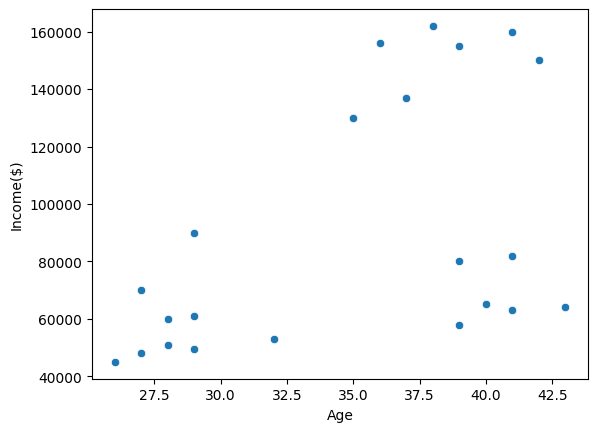

In [67]:
sns.scatterplot(data=df,x="Age",y="Income($)")

In [68]:
from sklearn.cluster import KMeans

In [69]:
kmc=KMeans(n_clusters=3)

In [70]:
model=kmc.fit(df[["Age","Income($)"]])

In [71]:
center=model.cluster_centers_
center

array([[3.29090909e+01, 5.61363636e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.40000000e+01, 8.05000000e+04]])

In [72]:
center[:,0]

array([32.90909091, 38.28571429, 34.        ])

In [73]:
center[:,1]

array([ 56136.36363636, 150000.        ,  80500.        ])

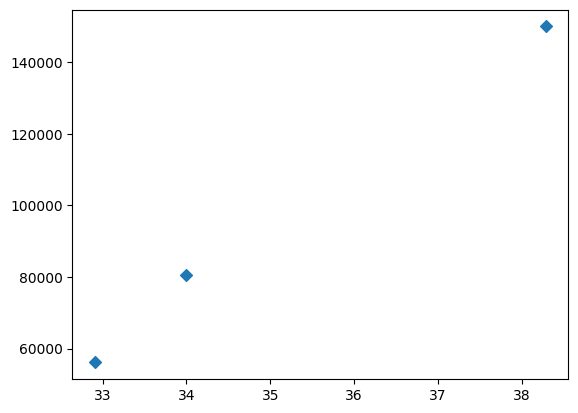

In [74]:
plt.scatter(center[:,0], center[:,1], marker='D')

In [75]:
model.labels_

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [76]:
df["cluster"]=model.labels_

In [77]:
df

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,1
9,Angelina,35,130000,1


In [80]:
df_0=df[df["cluster"]==0]
df_1=df[df["cluster"]==1]
df_2=df[df["cluster"]==2]

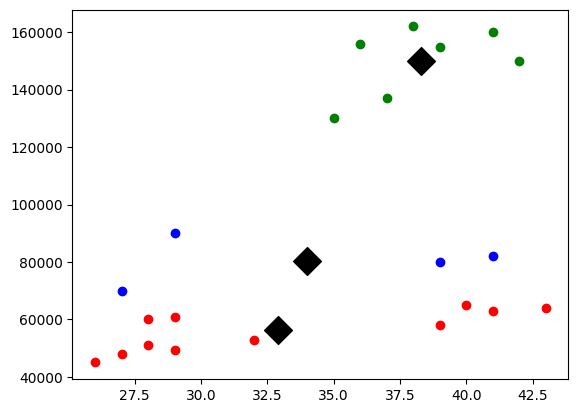

In [89]:
plt.scatter(df_0["Age"],df_0["Income($)"],color="red")
plt.scatter(df_1["Age"],df_1["Income($)"],color="green")
plt.scatter(df_2["Age"],df_2["Income($)"],color="blue")
plt.scatter(center[:,0],center[:,1],marker="D",color="black",s=200)

In [90]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [91]:
df[["Age","Income($)"]]=sc.fit_transform(df[["Age","Income($)"]])

Doing Code again after applying scaling

In [92]:
kmc=KMeans(n_clusters=3)

In [93]:
model=kmc.fit(df[["Age","Income($)"]])

In [94]:
center=model.cluster_centers_
center

array([[-1.1247901 , -0.74862223],
       [ 0.60143983,  1.40141653],
       [ 0.98550535, -0.51205261]])

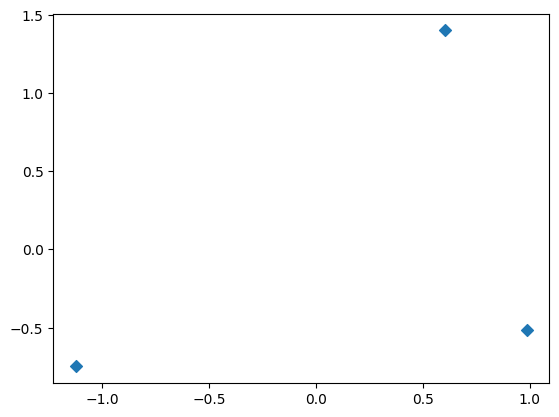

In [95]:
plt.scatter(center[:,0], center[:,1], marker='D')

In [96]:
model.labels_

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [97]:
df["cluster"]=model.labels_

In [98]:
df_0=df[df["cluster"]==0]
df_1=df[df["cluster"]==1]
df_2=df[df["cluster"]==2]

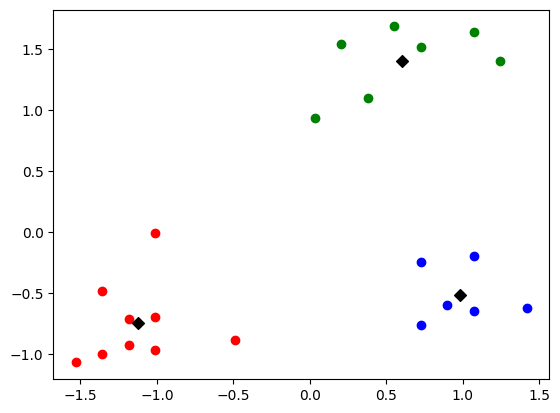

In [101]:
plt.scatter(df_0["Age"],df_0["Income($)"],color="red")
plt.scatter(df_1["Age"],df_1["Income($)"],color="green")
plt.scatter(df_2["Age"],df_2["Income($)"],color="blue")
plt.scatter(center[:,0],center[:,1],marker="D",color="black")